## ADP

**ADP** (Aerosol Data Protocol) is a protocol developed by Aerosol d.o.o. for standardized data exchange between instruments and data acquisition systems. It allows for real-time data retrieval, control and monitoring of compatible instruments.

ADP works with **AE36s**, **AE36**, **TCA08** and **TCA09** instruments, while **AE33 is not supported** (AE33 uses legacy AE33 data protocol, which behaves similarly, only commands are different).

**License:** Aerosol Magee Scientific Software License (See LICENSE file for full terms).

In [15]:
from datetime import timedelta, datetime
from io import StringIO

import pandas as pd

from aerosol_magee_pytools.data_access.tcp_ip import request_tcp, guess_delimiter
from aerosol_magee_pytools.instruments.column_names_types import COLUMNS_AE36S, COLUMNS_TCA09, COLUMNS_TCA08
from aerosol_magee_pytools.tools import dotnet_seconds_to_datetime

In [16]:
# IP of the instrument - change it to the actual IP address of your AE36s instrument
instrument_ip = '10.10.10.80' # Skylab AE36s
# instrument_ip = '10.10.10.133' # Skylab TCA08
# instrument_ip = '10.10.10.61' # Skylab TCA09

timeout = 2.0  # seconds

In [17]:
### command INFO
command = '$AERO:INFO\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

# parse info response to a dictionary
info = {}
for line in received_text.splitlines():
    line = line.strip()
    if not line or ':' not in line:
        continue
    key, value = line.split(':', 1)
    info[key.strip()] = value.strip()

# there are different fields in INFO response between TCA and AE36, let's synchronize info
if 'Serialnumber' in info:
    info['Serial Number'] = info.pop('Serialnumber' )
    info['Model number'] = info['Serial Number'].split('-')[0]

instrument_typ = info['Model number']
print()
print(f"Instrument type: {instrument_typ}")
print()
print(info)

Connection information
Serialnumber: AE36s-00-00107
Connection ID: 1019
Connection time: 23-Jun-2026 13:31:18
CPU used: 9 % , Memory used: 24 %

Instrument type: AE36s

{'Connection ID': '1019', 'Connection time': '23-Jun-2026 13:31:18', 'CPU used': '9 % , Memory used: 24 %', 'Serial Number': 'AE36s-00-00107', 'Model number': 'AE36s'}


In [18]:
### command LAST return entry from chosen table (table DATA in our case)
command = '$AERO:LAST DATA\r\n'
received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

5012206,639178110600000000,639178182600000000,56,1,1,0,0,0,0,1,0,10,10,0,S,864252.75,285843.25,587640.5,832209.125,272404.875,555986.125,837196,301532.75,576170.375,847045.25,318512.625,565450.125,851072,346385.75,574656.875,856535.625,422460.125,664907.25,861395.625,407961.25,601551.5,852279.5,484545.375,673822.375,846487.25,459942.125,623349.625,83.55675,27.76755,89.46533,29.51971,82.58028,26.76373,72.50285,22.93958,64.12605,19.83107,56.49658,17.07059,53.04234,15.90379,38.86965,10.99367,36.30235,10.24567,386,503,545,428,564,599,421,508,563,460,535,575,466,508,547,477,555,526,494,548,533,584,693,541,581,660,533,0.0034886,0.003176999,0.003061753,0.002757356,0.002315016,0.001644317,0.001381244,-0.002050207,-0.002435283,7.8,10.95789,11.05657,9.620693,8.366088,7.184634,6.088502,5.777446,4.200629,3.835183,0.08567715,1.065885,0.3793087,0.50108,0.07587671,-0.1768427,-0.09009933,0,0,84,101325,25,3766,1228,4994,2529,164,32.1,44.2,31.1,26.3,32.9,35.8,35.1,1388,281,8


**FETCH** command allows you to retrieve data from the instrument for a specific time period.

**Note:** On AE36, AE36s and TCA09, the data is stored in the table named `Data`, while on TCA08, data is stored in the table named `OnlineResults` (table named `Data` on TCA08 is acctually debug_data).

In [19]:
### command FETCH return data from chosen table and time period of last 24 hours on TCA or last 6 hours on Aethalometer

#### limit time to resent data
end = datetime.now().isoformat(sep=' ', timespec='seconds')
start = (datetime.now() - timedelta(hours=6)).isoformat(sep=' ', timespec='seconds')
if 'TCA' in instrument_typ:
    start = (datetime.now() - timedelta(days=1)).isoformat(sep=' ', timespec='seconds')
###

if instrument_typ != 'TCA08':
    # command = '$AERO:FETCH DATA "2026-06-11 12:51:00" "2026-06-11 15:51:00"\r\n'
    command = f'$AERO:FETCH DATA "{start}" "{end}"\r\n'
else:
    # command = '$AERO:FETCH OnlineResults "2026-06-11 12:51:00" "2026-06-11 15:51:00
    command = f'$AERO:FETCH OnlineResult "{start}" "{end}"\r\n'

received_text = request_tcp(ip=instrument_ip,
                            command=command,
                            timeout=timeout)
print(received_text)

5011847,639177895200000000,639177967200000000,56,1,1,0,0,0,0,1,0,10,10,0,0,879785.625,400367.125,672067.5,839641.875,385436.25,634841,842758,418095.625,649489.625,853790,429092,629716.5,856571,452408.75,630522.875,899258.625,560163.25,752606.875,867559.875,512266.375,649627.25,873183.875,586920.125,724840.5,869501.75,552945.5,670250.25,51.64421,16.12451,55.64587,17.14575,50.55928,15.44755,43.49504,12.96793,38.0668,11.19749,33.15074,9.548528,30.98815,8.92819,22.12505,6.118326,20.56899,5.673832,1122,1183,1351,1318,1381,1578,1347,1365,1585,1412,1316,1586,1401,1346,1523,1394,1301,1457,1412,1306,1465,1436,1258,1367,1472,1326,1392,0.003284763,0.002963854,0.002975295,0.002524278,0.002114849,0.001302924,0.001159637,-0.002271996,-0.002806582,13.7,27.15541,29.14948,27.08634,23.06324,20.01398,16.87429,15.87937,10.62513,10.00686,-0.3449154,3.87891,3.711058,3.16939,2.032991,1.026646,1.037919,0,0,825,101325,25,3779,1216,4995,2490,160,28.6,57,27,30.4,29.7,32.7,31,1388,277,8
5011848,639177895800000000

In [20]:
# in the end, you can parse data, for example, convert it into pandas dataframe;
# you will need column names first

if instrument_typ in ['AE36', 'AE36s']:
    columns = COLUMNS_AE36S['Data'].keys()
elif instrument_typ == 'TCA08':
    columns = COLUMNS_TCA08['OnlineResult'].keys()
elif instrument_typ == 'TCA09':
    columns = COLUMNS_TCA09['Data'].keys()
else:
    raise ValueError(f"Unsupported instrument type: {instrument_typ}")

# python can automatically determine the delimiter
separator = guess_delimiter(received_text)

df_data = pd.read_csv(StringIO(received_text.strip()),
                      sep=separator,
                      names=columns)

# convert instrument timestamps stored as nanoseconds from .NET epoch into pandas datetime
for column in df_data.columns:
    if ('Timestamp' in column) or column.endswith('TimeUTC') or column.endswith('TimeLocal'):
        if instrument_typ != 'TCA08':
            df_data[column] = dotnet_seconds_to_datetime(df_data[column])
        else:
            df_data[column] = pd.to_datetime(df_data[column])

print(df_data.shape)
print(df_data)

(360, 134)
          ID        TimestampUTC      TimestampLocal  SetupID  G0_Status  \
0    5011847 2026-06-23 05:32:00 2026-06-23 07:32:00       56          1   
1    5011848 2026-06-23 05:33:00 2026-06-23 07:33:00       56          1   
2    5011849 2026-06-23 05:34:00 2026-06-23 07:34:00       56          1   
3    5011850 2026-06-23 05:35:00 2026-06-23 07:35:00       56          1   
4    5011851 2026-06-23 05:36:00 2026-06-23 07:36:00       56          1   
..       ...                 ...                 ...      ...        ...   
355  5012202 2026-06-23 11:27:00 2026-06-23 13:27:00       56          1   
356  5012203 2026-06-23 11:28:00 2026-06-23 13:28:00       56          1   
357  5012204 2026-06-23 11:29:00 2026-06-23 13:29:00       56          1   
358  5012205 2026-06-23 11:30:00 2026-06-23 13:30:00       56          1   
359  5012206 2026-06-23 11:31:00 2026-06-23 13:31:00       56          1   

     G1_Status  G2_Status  G3_Status  G4_Status  G5_Status  G6_Status  \
0  

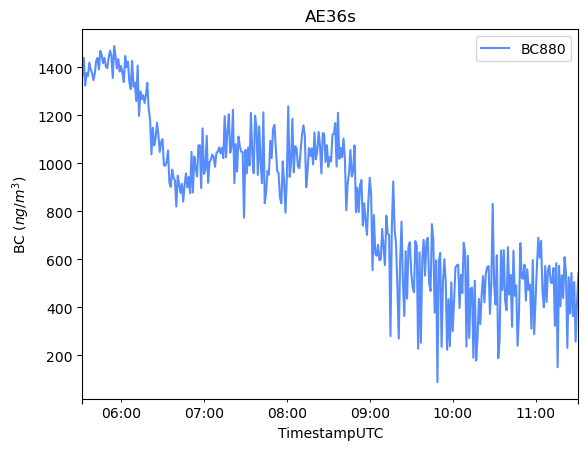

In [21]:
# plot data
if instrument_typ in ['AE36s', 'AE36']:
    df_data['TimestampUTC'] = pd.to_datetime(df_data['TimestampUTC'], errors='coerce')
    df_data.plot(x='TimestampUTC', y='BC880', title=f'{instrument_typ}', ylabel='BC ($ng/m^3$)')

elif instrument_typ == 'TCA08':
    df_data['EndTimeUTC'] = pd.to_datetime(df_data['EndTimeUTC'], errors='coerce')
    df_data.plot(x='EndTimeUTC', y='TCconc', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')

elif instrument_typ == 'TCA09':
    df_data = df_data[df_data['SampleEndTimeUTC'] != 0]
    df_data['SampleEndTimeUTC'] = pd.to_datetime(df_data['SampleEndTimeUTC'], errors='coerce')
    df_data.plot(x='SampleEndTimeUTC', y='TCconc_volume', title=f'{instrument_typ}', ylabel='TC ($ng/m^3$)')